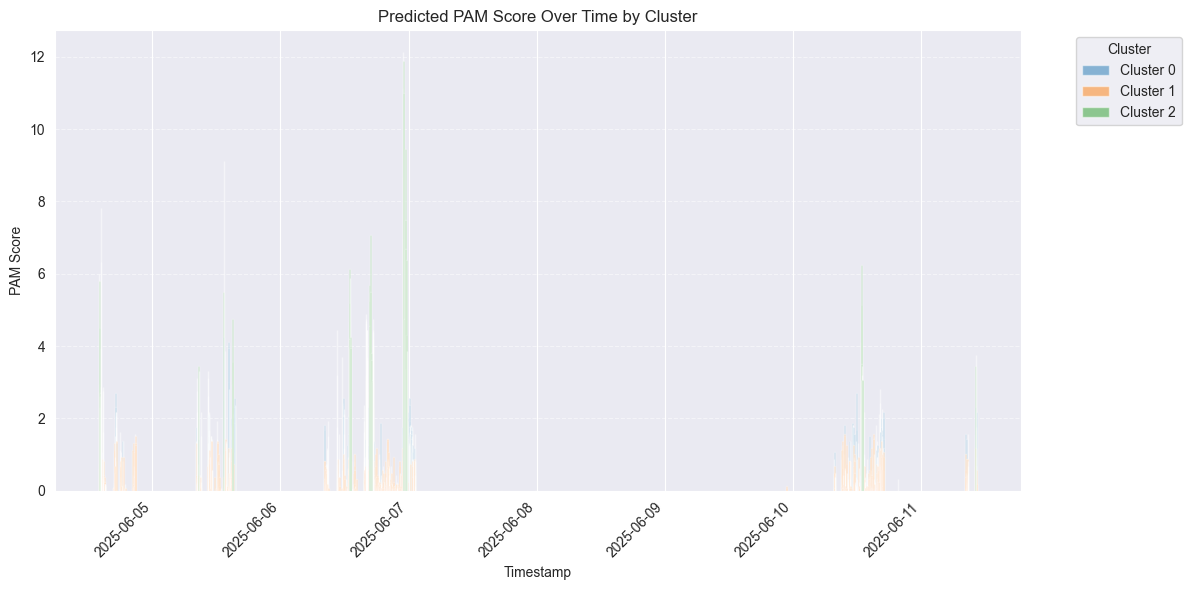

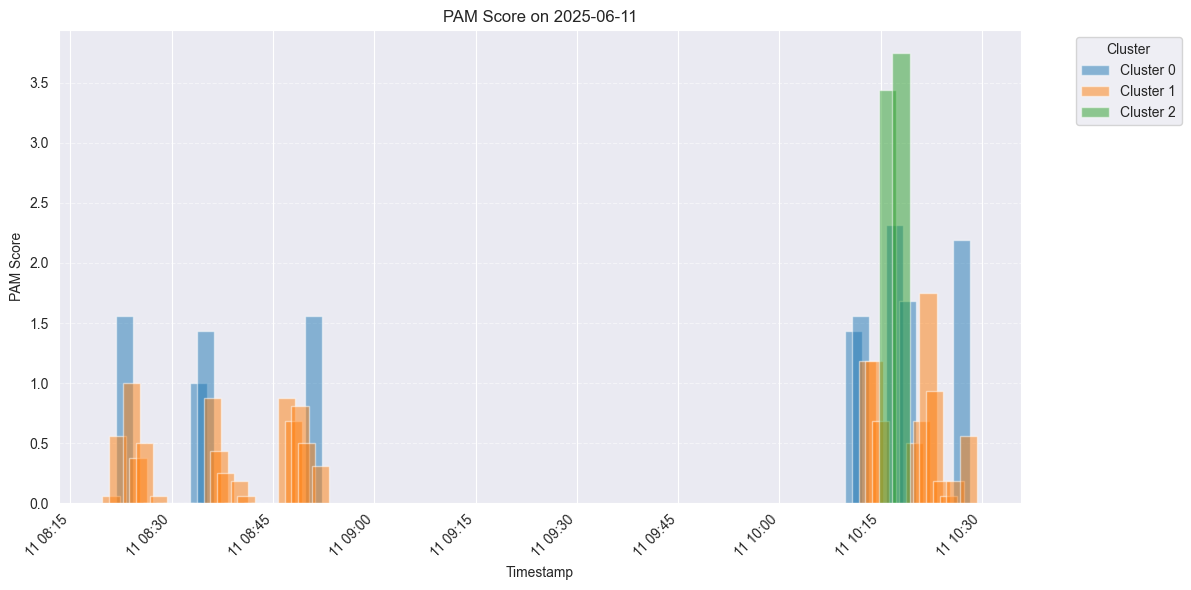

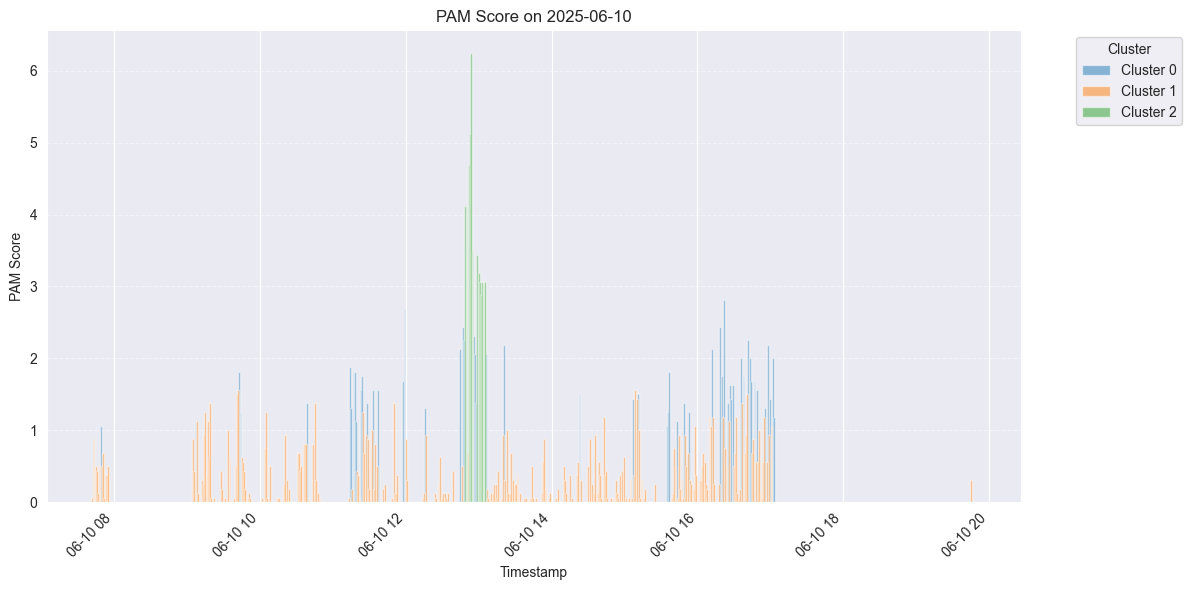

In [15]:
# display_labels.py
"""
Reads a labeled CSV and creates bar charts of PAM Score over time by cluster.
This version auto-calculates a reasonable bar width based on data span and point count.
Functions:
    plot_over_time(df: pd.DataFrame, title: str) -> None
    display_labels(input_csv: str) -> None
"""
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

def plot_over_time(df: pd.DataFrame, title: str) -> None:
    """
    Plot PAM Score over time with auto-scaled bar width.

    Args:
        df: DataFrame with `Timestamp`, `PAM Score`, and `predicted_label` columns.
        title: Chart title.
    """
    df = df.copy()
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df = df.dropna(subset=['Timestamp', 'PAM Score', 'predicted_label'])

    # Determine dynamic bar width: span divided by number of points
    tmin, tmax = df['Timestamp'].min(), df['Timestamp'].max()
    span = tmax - tmin
    n = len(df)
    if n > 0:
        bar_width = span / n
    else:
        bar_width = pd.Timedelta(minutes=1)

    plt.figure(figsize=(12, 6))
    for label in sorted(df['predicted_label'].unique()):
        subset = df[df['predicted_label'] == label]
        plt.bar(
            subset['Timestamp'],
            subset['PAM Score'],
            width=bar_width,
            alpha=0.5,
            label=f'Cluster {label}'
        )

    plt.xlabel('Timestamp')
    plt.ylabel('PAM Score')
    plt.title(title)
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def display_labels(input_csv: str) -> None:
    """
    Read labeled CSV and display three plots:
      1. Overall time series
      2. Last day only
      3. Day before last

    Args:
        input_csv: Path to the labeled CSV file.
    """
    df = pd.read_csv(input_csv)

    # Overall plot
    plot_over_time(df, 'Predicted PAM Score Over Time by Cluster')

    # Prepare date column
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df['Date'] = df['Timestamp'].dt.date
    last_date = df['Date'].max()
    day_before = last_date - timedelta(days=1)

    # Last day plot
    df_last = df[df['Date'] == last_date]
    if not df_last.empty:
        plot_over_time(df_last, f'PAM Score on {last_date}')
    else:
        print(f"No data for last date: {last_date}")

    # Day before last plot
    df_before = df[df['Date'] == day_before]
    if not df_before.empty:
        plot_over_time(df_before, f'PAM Score on {day_before}')
    else:
        print(f"No data for day before last date: {day_before}")

display_labels('11_06_2025_device_5___new_labeled.csv')